In [1]:
!pip install transformers accelerate einops opencv-python decord torch torchvision torchaudio matplotlib tqdm scikit-learn pandas av evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 92.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 MB 42.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.2 MB/s eta 0:00:00
  Attempting uninstal

In [2]:
import os
import numpy as np
import av
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import Trainer, TrainingArguments, VivitConfig, VivitForVideoClassification
import evaluate
import random


2025-11-14 09:35:11.449719: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763112911.631348      73 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763112911.691645      73 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def generate_all_files(root: Path, only_files: bool = True):
    for p in root.rglob("*"):
        if only_files and not p.is_file():
            continue
        yield p

def sample_frame_indices(clip_len, frame_sample_rate, seg_len):
    converted_len = int(clip_len * frame_sample_rate)
    end_idx = np.random.randint(converted_len, seg_len)
    start_idx = end_idx - converted_len
    indices = np.linspace(start_idx, end_idx, num=clip_len)
    indices = np.clip(indices, start_idx, end_idx-1).astype(np.int64)
    return indices

def read_video_pyav(container, indices):
    frames = []
    container.seek(0)
    start_index = indices[0]
    end_index = indices[-1]
    for i, frame in enumerate(container.decode(video=0)):
        if i > end_index:
            break
        if i >= start_index and i in indices:
            frames.append(frame.to_image())  # <-- NO resizing here
    return frames


In [4]:
from sklearn.model_selection import train_test_split

def get_video_paths_and_labels(root_dir):
    video_paths = []
    labels = []
    label2id = {}
    id2label = {}

    for idx, cls_folder in enumerate(sorted(os.listdir(root_dir))):
        cls_path = os.path.join(root_dir, cls_folder)
        if not os.path.isdir(cls_path):
            continue
        label2id[cls_folder] = idx
        id2label[idx] = cls_folder
        for file in os.listdir(cls_path):
            if file.endswith(".mp4"):
                video_paths.append(os.path.join(cls_path, file))
                labels.append(idx)

    return video_paths, labels, label2id, id2label

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=16, frame_sample_rate=1, 
                 image_size=224, is_training=True):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.frame_sample_rate = frame_sample_rate
        self.is_training = is_training
        
        # REDUCED augmentation intensity
        if is_training:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop((image_size, image_size), scale=(0.85, 1.0)),  # Less aggressive
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),  # Reduced
                transforms.RandomRotation(degrees=10),  # Reduced from 15
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
            
    def __len__(self):
        return len(self.video_paths)
    
    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        
        container = av.open(video_path)
        indices = sample_frame_indices(self.num_frames, self.frame_sample_rate, 
                                      container.streams.video[0].frames)
        frames = read_video_pyav(container, indices)
        frames = [self.transform(frame) for frame in frames]
        video_tensor = torch.stack(frames)
        
        return {"pixel_values": video_tensor, "labels": label}

In [5]:
metric = evaluate.load("accuracy", trust_remote_code=True)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    return metric.compute(predictions=preds, references=p.label_ids)

In [6]:
def initialise_model(device="cuda", model_name="google/vivit-b-16x2-kinetics400"):
    label2id = {"NonViolence": 0, "Violence": 1}
    id2label = {0: "NonViolence", 1: "Violence"}
    
    config = VivitConfig.from_pretrained(model_name)
    config.num_labels = len(label2id)
    config.label2id = label2id
    config.id2label = id2label
    config.num_frames = 16
    config.image_size = 224
    config.hidden_dropout_prob = 0.3  # Increased dropout
    config.attention_probs_dropout_prob = 0.3  # Add attention dropout

    model = VivitForVideoClassification.from_pretrained(
        model_name,
        ignore_mismatched_sizes=True,
        config=config
    ).to(device)

    return model

In [20]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/results",
    eval_strategy="steps",
    save_strategy="steps",
    eval_steps=50,
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=20,
    logging_first_step=True,
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=3e-6,
    weight_decay=0.01,
    warmup_ratio=0.1,
    label_smoothing_factor=0.1,
    optim="adamw_torch",
    lr_scheduler_type="cosine",
    fp16=True,
    gradient_accumulation_steps=2,
    max_grad_norm=1.0,
    seed=42,
    dataloader_num_workers=2,
    report_to="none"
)

In [21]:
video_paths, labels, label2id, id2label = get_video_paths_and_labels("/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset")

train_videos, temp_videos, train_labels, temp_labels = train_test_split(
    video_paths, labels, test_size=0.3, stratify=labels, random_state=42
)

# Now split temp into val and test
val_videos, test_videos, val_labels, test_labels = train_test_split(
    temp_videos, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

# Dataset prep
train_dataset = VideoDataset(train_videos, train_labels, is_training=True)
val_dataset = VideoDataset(val_videos, val_labels, is_training=False)
test_dataset = VideoDataset(test_videos, test_labels, is_training=False)

# Initialize model
model = initialise_model()

Some weights of VivitForVideoClassification were not initialized from the model checkpoint at google/vivit-b-16x2-kinetics400 and are newly initialized because the shapes did not match:
- vivit.embeddings.position_embeddings: found shape torch.Size([1, 3137, 768]) in the checkpoint and torch.Size([1, 1569, 768]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
from transformers import EarlyStoppingCallback, TrainerCallback

class MetricsCallback(TrainerCallback):
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            print(f"\nStep {state.global_step}:")
            print(f"  Validation Loss: {metrics.get('eval_loss', 'N/A'):.4f}")
            print(f"  Validation Accuracy: {metrics.get('eval_accuracy', 'N/A'):.4f}")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=10),  # Increased patience
        MetricsCallback()
    ]
)

trainer.train()

Step,Training Loss,Validation Loss,Accuracy
50,0.707800,0.722047,0.505119
100,0.637200,0.679646,0.597270
150,0.609100,0.650149,0.648464
200,0.536800,0.630976,0.662116
250,0.538100,0.617678,0.696246
300,0.472600,0.591106,0.686007
350,0.506100,0.598184,0.689420
400,0.478900,0.611093,0.706485
450,0.454900,0.593930,0.692833
500,0.447800,0.592207,0.709898



Step 50:
  Validation Loss: 0.7220
  Validation Accuracy: 0.5051

Step 100:
  Validation Loss: 0.6796
  Validation Accuracy: 0.5973

Step 150:
  Validation Loss: 0.6501
  Validation Accuracy: 0.6485

Step 200:
  Validation Loss: 0.6310
  Validation Accuracy: 0.6621

Step 250:
  Validation Loss: 0.6177
  Validation Accuracy: 0.6962

Step 300:
  Validation Loss: 0.5911
  Validation Accuracy: 0.6860

Step 350:
  Validation Loss: 0.5982
  Validation Accuracy: 0.6894

Step 400:
  Validation Loss: 0.6111
  Validation Accuracy: 0.7065

Step 450:
  Validation Loss: 0.5939
  Validation Accuracy: 0.6928

Step 500:
  Validation Loss: 0.5922
  Validation Accuracy: 0.7099

Step 550:
  Validation Loss: 0.5808
  Validation Accuracy: 0.7201

Step 600:
  Validation Loss: 0.5758
  Validation Accuracy: 0.7133

Step 650:
  Validation Loss: 0.5753
  Validation Accuracy: 0.7201

Step 700:
  Validation Loss: 0.5786
  Validation Accuracy: 0.7270

Step 750:
  Validation Loss: 0.5667
  Validation Accuracy: 0.7

TrainOutput(global_step=850, training_loss=0.5064744524394764, metrics={'train_runtime': 4299.3247, 'train_samples_per_second': 3.175, 'train_steps_per_second': 0.198, 'total_flos': 1.7060158307594207e+19, 'train_loss': 0.5064744524394764, 'epoch': 9.88888888888889})

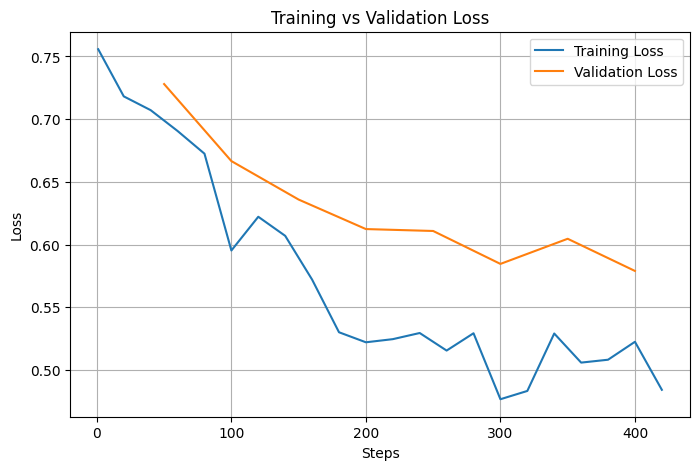

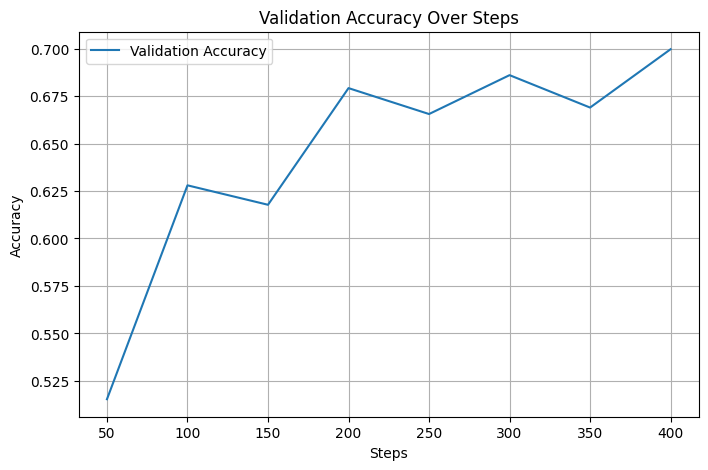

In [10]:
import matplotlib.pyplot as plt

# Extract log history
logs = trainer.state.log_history

# Extract step numbers
train_loss_steps = [log["step"] for log in logs if "loss" in log]
eval_loss_steps = [log["step"] for log in logs if "eval_loss" in log]
eval_acc_steps = [log["step"] for log in logs if "eval_accuracy" in log]

# Extract metric values
train_loss = [log["loss"] for log in logs if "loss" in log]
eval_loss = [log["eval_loss"] for log in logs if "eval_loss" in log]
eval_accuracy = [log["eval_accuracy"] for log in logs if "eval_accuracy" in log]

# --- Combined Train + Val Loss Plot ---
plt.figure(figsize=(8, 5))
plt.plot(train_loss_steps, train_loss, label="Training Loss")
plt.plot(eval_loss_steps, eval_loss, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

# --- Validation Accuracy Plot ---
plt.figure(figsize=(8, 5))
plt.plot(eval_acc_steps, eval_accuracy, label="Validation Accuracy")
plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Steps")
plt.grid(True)
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import classification_report
import numpy as np

In [12]:
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

In [13]:
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in sorted(id2label)]))

              precision    recall  f1-score   support

 NonViolence       0.67      0.86      0.75       143
    Violence       0.82      0.59      0.69       150

    accuracy                           0.72       293
   macro avg       0.74      0.73      0.72       293
weighted avg       0.74      0.72      0.72       293



In [14]:
trainer.save_model("vivit-violence-detection-model-v5")

In [15]:
import torch
import av
import numpy as np
from torchvision import transforms
from transformers import VivitForVideoClassification, VivitConfig

# --- Configuration ---
NUM_FRAMES = 16
IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load model from your checkpoint folder ---
checkpoint_path = "/kaggle/input/vivit-model-v4/transformers/default/1"  
model = VivitForVideoClassification.from_pretrained(checkpoint_path).to(DEVICE)
model.eval()

# --- Preprocessing transform ---
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  
])

# --- Video Loading Function ---
def load_video(video_path, num_frames=NUM_FRAMES):
    container = av.open(video_path)
    frames = []
    for frame in container.decode(video=0):
        img = frame.to_image()
        frames.append(transform(img))
        if len(frames) == num_frames:
            break
    container.close()
    if len(frames) < num_frames:
        # Pad with last frame
        frames += [frames[-1]] * (num_frames - len(frames))
    video_tensor = torch.stack(frames).unsqueeze(0).to(DEVICE)  # shape: (1, T, C, H, W)
    return video_tensor 

# --- Run Inference ---
video_tensor = load_video("/kaggle/input/non-violence-inference-video/videoplayback.mp4")
with torch.no_grad():
    outputs = model(video_tensor)
    pred_class = torch.argmax(outputs.logits, dim=1).item()

In [16]:
model.config.id2label = {
    0: "non-violent",
    1: "violent"
}
model.config.label2id = {
    "non-violent": 0,
    "violent": 1
}

In [17]:
print("Predicted class:", model.config.id2label[pred_class])

Predicted class: non-violent


In [18]:
import shutil
shutil.make_archive("vivit-violence-detection-model-v5", 'zip', "vivit-violence-detection-model-v5")

'/kaggle/working/vivit-violence-detection-model-v5.zip'

In [19]:
from IPython.display import FileLink
FileLink(r'vivit-violence-detection-model-v5.zip')

/kaggle/working/vivit-violence-detection-model-v5.zip